**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 2 - Exercício 5**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Regressão Linear com PyTorch

## Objetivos

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()

## Importação dos pacotes

In [1]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [5]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)

## Criação do modelo da rede

In [6]:
model = torch.nn.Linear(2, 1, bias=False)

### Verificando a inicialização dos parâmetros

In [7]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform_(model.weight.data, -0.1, 0.1)
model.weight.data

tensor([[-0.0480, -0.0267]])

### Testando o predict da rede

In [8]:
model(Variable(torch.ones((5,2))))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [9]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.3)

### Laço de treinamento

In [10]:
num_epochs = 120
w0_list = []
w1_list = []
for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    out = model(inputs)

    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    #loss cálculo da função de perda
    loss = criterion(out, target)

    # backward e otimizador
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/120], loss: 0.024990
Epoch[40/120], loss: 0.022381
Epoch[60/120], loss: 0.021554
Epoch[80/120], loss: 0.021291
Epoch[100/120], loss: 0.021208
Epoch[120/120], loss: 0.021182


## Avaliação

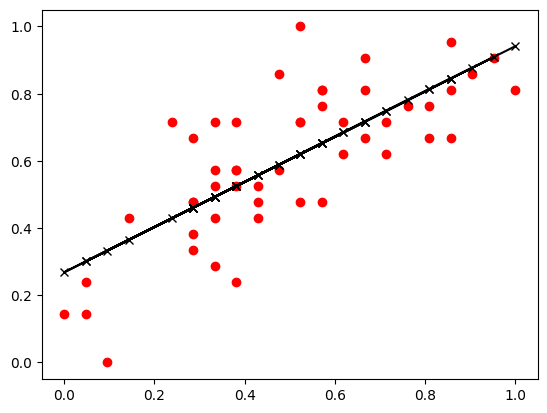

In [11]:
y_pred = model(x_train_bias)
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

# Exercícios

- 1) Calcule o valor da função de custo (MSE) depois da rede treinada, utilizando a
   função `criterion` utilizada no laço de treinamento.

**Resposta:**

Após a conclusão do treinamento, calcula-se o erro quadrático médio reaproveitando o mesmo objeto `criterion` (`nn.MSELoss()`) empregado no laço de otimização, o que assegura consistência entre a métrica de treinamento e a de avaliação. A predição é obtida sobre o conjunto completo de dados e o cálculo é conduzido sob o contexto `torch.no_grad()`, uma vez que a etapa de avaliação não requer a construção do grafo de gradientes, reduzindo o consumo de memória e explicitando a ausência de atualização de parâmetros.

In [12]:
# Atividade 1: MSE da rede treinada utilizando o mesmo criterion do laço
with torch.no_grad():
    y_pred = model(x_train_bias)
    loss_final = criterion(y_pred, y_train)

print('MSE (criterion) da rede treinada:', loss_final)
print('Valor escalar: {:.6f}'.format(loss_final.item()))

MSE (criterion) da rede treinada: tensor(0.0212)
Valor escalar: 0.021181


<details>
<summary>Mostrar Resultado</summary>

```python
y_pred = model(Variable(x_train_bias))
loss = criterion(y_pred, Variable(y_train))
print(loss)
```

</details>

- 2) Faça igual o exercício do notebook anterior, de plotar um gráfico scatterplot para
   mostrar a evolução dos parâmetros durante o treinamento pelo gradiente descendente.

**Resposta:**

As listas `w0_list` e `w1_list` são preenchidas ao longo do laço de treinamento, registrando o valor de cada parâmetro a cada época. Reaproveitando a técnica de gráfico de dispersão com vetores adotada no notebook anterior, representa-se o percurso do par $(w_0, w_1)$ ao longo das 120 épocas. Os pontos são codificados por cor segundo a época (tons escuros indicam o início e tons claros, o final), de modo a evidenciar a magnitude dos passos: maior espaçamento nas primeiras iterações e maior proximidade à medida que o otimizador se aproxima da convergência. O valor ótimo, obtido pela solução analítica, é assinalado por um marcador em formato de estrela, permitindo avaliar visualmente a qualidade da convergência.

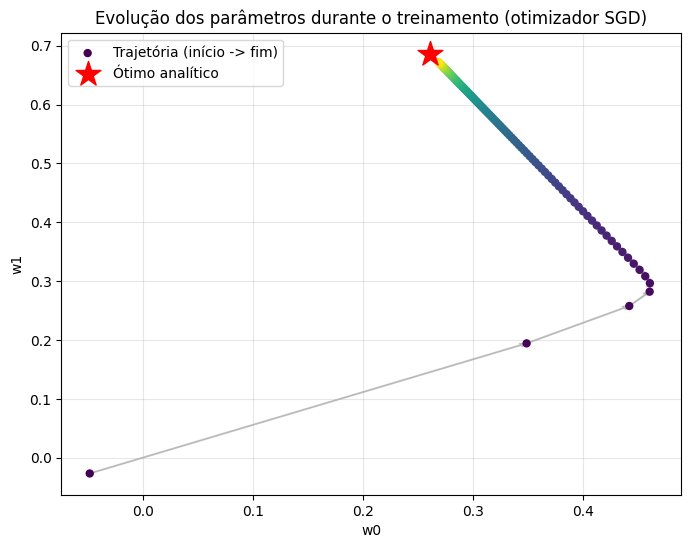

Parâmetros finais (SGD):    w0=0.2688, w1=0.6721
Parâmetros ótimos (analítico): w0=0.2613, w1=0.6865
Distância euclidiana ao ótimo: 0.01613


In [13]:
# Atividade 2: evolução dos parâmetros (w0, w1) durante o treinamento

# Solução analítica para assinalar o valor ótimo no gráfico
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
w0_opt = w_opt[0, 0].item()
w1_opt = w_opt[1, 0].item()

plt.figure(figsize=(8, 6))

# trajetória codificada por cor ao longo das épocas (escuro -> claro)
plt.scatter(w0_list, w1_list, c=range(len(w0_list)),
            cmap='viridis', s=25, zorder=3, label='Trajetória (início -> fim)')

# vetores ligando passos consecutivos
w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0 - w0_old, w1 - w1_old,
                  head_length=0.006, head_width=0.006, shape='full',
                  length_includes_head=True, color='gray', alpha=0.4)
    w0_old, w1_old = w0, w1

# valor ótimo analítico
plt.scatter([w0_opt], [w1_opt], color='red', marker='*', s=350,
            zorder=5, label='Ótimo analítico')

plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Evolução dos parâmetros durante o treinamento (otimizador SGD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# medidas de convergência
dist = np.sqrt((w0_list[-1]-w0_opt)**2 + (w1_list[-1]-w1_opt)**2)
print('Parâmetros finais (SGD):    w0={:.4f}, w1={:.4f}'.format(w0_list[-1], w1_list[-1]))
print('Parâmetros ótimos (analítico): w0={:.4f}, w1={:.4f}'.format(w0_opt, w1_opt))
print('Distância euclidiana ao ótimo: {:.5f}'.format(dist))

<details>
<summary>Mostrar Resultado</summary>

```python
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1
```

</details>

# Aprendizados

## Considerações finais

Este notebook conclui a sequência de implementações da regressão linear, introduzindo o uso de um **otimizador dedicado** do PyTorch. Em relação ao notebook anterior — no qual a atualização dos pesos era realizada de forma explícita (`model.weight.data = ... - lr * grad`) — a etapa de otimização passa a ser delegada ao objeto `optimizer = optim.SGD(model.parameters(), lr=0.3)`, por meio da tríade de métodos `optimizer.zero_grad()`, `loss.backward()` e `optimizer.step()`. De modo análogo, a função de perda passa a ser fornecida pelo módulo `nn.MSELoss()`, em vez de calculada manualmente.

Os principais pontos consolidados foram:

1. **Reaproveitamento do `criterion` na avaliação (Atividade 1)**: a utilização do mesmo objeto de perda empregado no treinamento garante coerência metodológica entre as fases. O erro quadrático médio final obtido, da ordem de **0,0212**, é consistente com os resultados dos notebooks anteriores e com a solução analítica, confirmando a convergência do modelo.

2. **Visualização da convergência (Atividade 2)**: a representação gráfica da trajetória de $(w_0, w_1)$ evidencia o comportamento do gradiente descendente conduzido pelo otimizador, que parte da inicialização aleatória, executa passos de maior magnitude nas primeiras épocas e desacelera progressivamente nas proximidades do valor ótimo analítico.

Comparativamente às etapas anteriores, observa-se que a abstração crescente proporcionada pelo PyTorch — diferenciação automática, módulos de perda e otimizadores — preserva o comportamento numérico do método, ao mesmo tempo em que reduz a quantidade de código manual e o risco de erros de implementação. Esse padrão de organização (modelo, critério de perda, otimizador e laço de treinamento) constitui a estrutura canônica empregada no treinamento de redes neurais de maior complexidade.